# Proyecto de Machine Learning: apoyo a la caracterización clínica (datos GRD — Hospital El Pino)

**Dataset principal:** `dataset_elpino.csv`



## 1. Carga de datos e importaciones

Se importan librerías estándar para manipulación tabular, visualización y *scikit-learn*.  
Se fija una semilla (`RANDOM_STATE`) para reproducibilidad.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("dataset_elpino.csv")
CLEAN_PATH = Path("dataset_elpino_clean.csv")
CIE10_PATH = Path("CIE-10.xlsx")  # opcional: tablas maestras complementarias

print("Entorno listo. Rutas:")
print(" -", DATA_PATH.resolve())
print(" - salida limpia:", CLEAN_PATH.resolve())


Entorno listo. Rutas:
 - C:\Users\Alvar\OneDrive\Escritorio\aprendizaje-maquina\dataset_elpino.csv
 - salida limpia: C:\Users\Alvar\OneDrive\Escritorio\aprendizaje-maquina\dataset_elpino_clean.csv


### 1.1 Lectura del CSV

El archivo utiliza **separador `;`**. Se intenta `utf-8` y, si falla, `latin-1` (común en exportaciones regionales).


In [2]:
def read_elpino_csv(path: Path) -> pd.DataFrame:
    for enc in ("utf-8", "latin-1"):
        try:
            return pd.read_csv(path, sep=";", encoding=enc, low_memory=False)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, sep=";", encoding="utf-8", errors="replace", low_memory=False)


df_raw = read_elpino_csv(DATA_PATH)
print("Dimensiones (filas, columnas):", df_raw.shape)
df_raw.head()


Dimensiones (filas, columnas): (14561, 68)


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,99.84 - AISLAMIENTO,88.72 - ECOCARDIOGRAFIA,90.42 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTIVO,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,87.03 - TOMOGRAFIA AXIAL COMPUTERIZADA CABEZA,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,91.62 - EXAMEN MICROSCOPICO PIEL.CULTIVO,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,96.59 - IRRIGACION HERIDA OTRA,90.99 - EXAMEN MICROSCOPICO DIGESTIVO INFERIOR...,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.84 - AISLAMIENTO,91.73 - EXAMEN MICROSCOPICO HERIDA OPERATORIA....,90.53 - EXAMEN MICROSCOPICO SANGRE.CULTIVO Y S...,99.26 - INYECCION TRANQUILIZANTE,89.39 - OTRAS MEDICIONES Y EXAMENES NO QUIRURG...,89.66 - GASOMETRIA VENA,89.65 - GASOMETRIA ARTERIA,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,57.94 - SONDAJE URINARIO PERMANENTE,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.04 - TRANSFUSION CONCENTRADO HEMATIES,99.18 - INYECCION ELECTROLITO,99.21 - INYECCION ANTIBIOTICO,99.23 - INYECCION ESTEROIDE,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,90.52 - EXAMEN MICROSCOPICO SANGRE.CULTIVO,91.39 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,91.32 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,93.

In [3]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 14561 entries, 0 to 14560
Data columns (total 68 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Diag 01 Principal (cod+des)     14561 non-null  str  
 1   Diag 02 Secundario (cod+des)    14561 non-null  str  
 2   Diag 03 Secundario (cod+des)    14561 non-null  str  
 3   Diag 04 Secundario (cod+des)    14561 non-null  str  
 4   Diag 05 Secundario (cod+des)    14561 non-null  str  
 5   Diag 06 Secundario (cod+des)    14561 non-null  str  
 6   Diag 07 Secundario (cod+des)    14561 non-null  str  
 7   Diag 08 Secundario (cod+des)    14561 non-null  str  
 8   Diag 09 Secundario (cod+des)    14561 non-null  str  
 9   Diag 10 Secundario (cod+des)    14561 non-null  str  
 10  Diag 11 Secundario (cod+des)    14561 non-null  str  
 11  Diag 12 Secundario (cod+des)    14561 non-null  str  
 12  Diag 13 Secundario (cod+des)    14561 non-null  str  
 13  Diag 14 Secu

In [4]:
df_raw.describe(include="all").transpose().head(25)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Diag 01 Principal (cod+des),14561,1491,O70.0 - Desgarro perineal de primer grado dura...,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 02 Secundario (cod+des),14561,1717,-,1209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 03 Secundario (cod+des),14561,1498,-,2687,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 04 Secundario (cod+des),14561,1304,-,4127,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 05 Secundario (cod+des),14561,1151,-,5371,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 06 Secundario (cod+des),14561,982,-,6394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 07 Secundario (cod+des),14561,838,-,7408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 08 Secundario (cod+des),14561,752,-,8584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 09 Secundario (cod+des),14561,664,-,9719,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diag 10 Secundario (cod+des),14561,598,-,10696,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Limpieza de datos

### Criterios documentados

1. **Homogeneizar valores faltantes:** en este dataset, muchos campos ausentes aparecen como guion `"-"` en lugar de `NaN`. Los tratamos como faltantes en columnas de diagnóstico y procedimiento.  
2. **Duplicados:** se eliminan filas idénticas para evitar sobre-representación artificial.  
3. **Columnas irrelevantes o casi vacías:** se eliminan columnas de procedimiento con **más del 85%** de valores faltantes tras la conversión, porque aportan poco señal estable y aumentan ruido dimensional.  
4. **Filtrado de registros:** se descartan filas sin edad válida o sin sexo; se acota edad a un rango clínico razonable `[0, 110]` para mitigar errores de captura (*outliers extremos evidentes*).

Al finalizar, se exporta **`dataset_elpino_clean.csv`** para trazabilidad y reutilización.


In [5]:
def dash_to_nan(s: pd.Series) -> pd.Series:
    s2 = s.copy()
    s2 = s2.replace({"-": np.nan, "": np.nan, None: np.nan})
    return s2


df = df_raw.copy()

diag_cols = [c for c in df.columns if c.startswith("Diag ")]
proc_cols = [c for c in df.columns if c.startswith("Proced ")]

for c in diag_cols + proc_cols:
    df[c] = dash_to_nan(df[c])

# Tipos: edad numérica
age_col = "Edad en años" if "Edad en años" in df.columns else [c for c in df.columns if "Edad" in c][0]
df[age_col] = pd.to_numeric(df[age_col], errors="coerce")

before = len(df)
df = df.drop_duplicates()
print(f"Duplicados eliminados: {before - len(df)} filas")

# Columnas procedimiento con alta ausencia
missing_frac = df[proc_cols].isna().mean().sort_values(ascending=False)
drop_proc = missing_frac[missing_frac > 0.85].index.tolist()
print("Columnas Procedimiento descartadas (>85% faltantes):", len(drop_proc))
df = df.drop(columns=drop_proc)

# Filas coherentes
df = df.dropna(subset=[age_col, "Sexo (Desc)"])
df = df[(df[age_col] >= 0) & (df[age_col] <= 110)]

print("Dimensiones tras limpieza:", df.shape)
df.head()


Duplicados eliminados: 144 filas
Columnas Procedimiento descartadas (>85% faltantes): 8
Dimensiones tras limpieza: (14416, 60)


,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 16 Secundario (cod+des),Proced 17 Secundario (cod+des),Proced 18 Secundario (cod+des),Proced 19 Secundario (cod+des),Proced 20 Secundario (cod+des),Proced 21 Secundario (cod+des),Proced 22 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,A41.8 - Otras septicemias especificadas,B37.6 - Endocarditis debida a candida (I39.8*),"I39.8 - Endocarditis, válvula no especificada,...",N10 - Nefritis tubulointersticial aguda,B96.1 - Klebsiella pneumoniae [K. pneumoniae] ...,L89.9 - Úlcera de decúbito y area de presión n...,L08.9 - Infección local de la piel y del tejid...,B96.2 - Escherichia coli [E. coli] como causa ...,A41.5 - Sepsis por otros organnismos Gram nega...,J86.9 - Piotórax sin fístula,...,93.94 - AEROSOLTERAPIA,89.52 - ELECTROCARDIOGRAFIA,90.59 - EXAMEN MICROSCOPICO SANGRE.OTRO,89.65 - GASOMETRIA ARTERIA,39.95 - HEMODIALISIS,39.95 - HEMODIALISIS,99.04 - TRANSFUSION CONCENTRADO HEMATIES,40,Hombre,184103 - MH SEPTICEMIA W/MCC
1,"U07.1 - COVID-19, virus identificado",J12.8 - Neumonía debida a otros virus,R06.0 - Disnea,R05 - Tos,"R50.9 - Fiebre, no especificada",Z29.0 - Aislamiento,Z01.7 - Examen de laboratorio,"J96.00 - Insuficiencia respiratoria aguda, Tip...",J94.2 - Hemotórax,J92.9 - Paquipleuritis sin asbestosis,...,00.17 - INFUSON AGENTE VASOPRESOR,99.21 - INYECCION ANTIBIOTICO,99.18 - INYECCION ELECTROLITO,99.26 - INYECCION TRANQUILIZANTE,99.23 - INYECCION ESTEROIDE,89.65 - GASOMETRIA ARTERIA,91.69 - EXAMEN MICROSCOPICO PIEL.OTRO,53,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
2,K56.5 - Adherencias [bridas] intestinales con ...,R57.2 - Shock séptico,R57.1 - Choque hipovolémico,J80 - Síndrome de dificultad respiratoria del ...,Y95 - Afección nosocomial,J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,B95.6 - Staphylococcus aureus como causa de en...,B96.8 - Otros agentes bacterianos especificado...,B37.1 - Candidiasis pulmonar,...,99.21 - INYECCION ANTIBIOTICO,99.04 - TRANSFUSION CONCENTRADO HEMATIES,93.96 - ENRIQUECIMIENTO OXIGENO OTRO,91.83 - EXAMEN MICROSCOPICO OTRO.CULTIVO Y SEN...,90.43 - EXAMEN MICROSCOPICO RESPIRATORIO.CULTI...,38.93 - CATETERISMO VENA OTRO,91.33 - EXAMEN MICROSCOPICO URINARIO INFERIOR....,65,Hombre,041013 - PH ECMO VENTILACIÓN MECÁNICA PROLONGA...
3,K76.8 - Otras enfermedades especificadas del h...,K66.1 - Hemoperitoneo,"N18.5 - Enfermedad renal crónica, estadio 5",D64.9 - Anemia de tipo no especificado,E87.5 - Hiperpotasemia,E87.2 - Acidosis,J81 - Edema pulmonar,N17.8 - Otras insuficiencias renales agudas,J44.9 - Enfermedad pulmonar obstructiva crónic...,R41.0 - Desorientación no especificada,...,89.52 - ELECTROCARDIOGRAFIA,45.13 - ESOFAGOGASTRODUODENOSCOPIA [EGD],38.93 - CATETERISMO VENA OTRO,38.91 - CATETERISMO ARTERIA,38.95 - CATETERISMO VENA PARA DIALISIS RIÑON,39.95 - HEMODIALISIS,96.59 - IRRIGACION HERIDA OTRA,61,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...
4,T81.0 - Hemorragia y hematoma que complican un...,"Y83.2 - Operación quirúrgica con anastomosis, ...",S31.1 - Herida de la pared abdominal,S36.80 - Traumatismo de otros órganos intraabd...,W31.62 - Contacto traumático con otras maquina...,"J96.09 - Insuficiencia respiratoria aguda, Tip...",J15.0 - Neumonía debida a Klebsiella pneumoniae,U82.2 - Resistencia a Betalactamasas de amplio...,"U07.1 - COVID-19, virus identificado","N39.0 - Infección de vías urinarias, sitio no ...",...,93.96 - ENRIQUECIMIENTO OXIGENO OTRO,00.13 - INYECCION NESIRITIDE,00.17 - INFUSON AGENTE VASOPRESOR,99.18 - INYECCION ELECTROLITO,99.26 - INYECCION TRANQUILIZANTE,99.19 - INYECCION ANTICOAGULANTE,99.21 - INYECCION ANTIBIOTICO,30,Hombre,041023 - PH VENTILACIÓN MECÁNICA PROLONGADA SI...


In [6]:
# Persistencia del dataset limpio (requisito del proyecto)
df.to_csv(CLEAN_PATH, sep=";", index=False, encoding="utf-8")
print("Archivo guardado:", CLEAN_PATH.resolve(), "—", CLEAN_PATH.stat().st_size, "bytes")


Archivo guardado: C:\Users\Alvar\OneDrive\Escritorio\aprendizaje-maquina\dataset_elpino_clean.csv — 14052257 bytes


## 3. Ingeniería de características y preprocesamiento

### 3.1 Extracción de códigos CIE-10 (prefijo)

Se extrae el **código al inicio** del campo `cod+des` con una expresión regular conservadora.

### 3.2 Variable objetivo (sin filtración desde `X`)

- **`y_resp_primario_J` = 1** si el diagnóstico principal comienza por **`J`** (capítulo respiratorio CIE-10).  
- **Regla de oro** para entrenamiento: se calcula desde `Diag 01 Principal`, pero **esa columna no entra en `X`**.

### 3.3 Predictores en `X`

- `edad`  
- `sexo` (categórica)  
- Agregados desde diagnósticos **secundarios** (02–35): conteos por **letra-capitulo** y presencia de patrones frecuentes (`U07` COVID-19, `J`, `A`, etc.)  
- Agregados desde **procedimientos** restantes: número de procedimientos informados y conteo de prefijos numéricos (dos primeros dígitos del código de procedimiento).

### 3.4 Codificación y escalado

- **One-Hot Encoding** para sexo (baja cardinalidad): equivalente a *dummy variables* y evita suponer un orden artificial entre categorías. Para un bosque aleatorio también sería válido un **Label Encoding** al ser un modelo no paramétrico basado en particiones; se prioriza *One-Hot* por transparencia en informes académicos.  
- **StandardScaler** en variables numéricas continuas/conteos: aunque *Random Forest* no exige escalado, se deja aplicado dentro de un `Pipeline` por consistencia docente y por si se reutiliza el mismo preprocesamiento con otros modelos.


In [7]:
import re
from typing import Optional

PRINCIPAL_COL = "Diag 01 Principal (cod+des)"
SEXO_COL = "Sexo (Desc)"


def extract_icd_code(text) -> Optional[str]:
    if pd.isna(text):
        return None
    s = str(text).strip()
    m = re.match(r"^([A-TV-Z][0-9]{2}\.[0-9A-Z]+|[A-TV-Z][0-9]{2})", s)
    if m:
        return m.group(1)
    m2 = re.match(r"^(U07\.[0-9])", s)
    if m2:
        return m2.group(1)
    return None


def extract_proc_prefix(text) -> Optional[str]:
    if pd.isna(text):
        return None
    s = str(text).strip()
    m = re.match(r"^([0-9]{2}\.[0-9]{2})", s)
    return m.group(1) if m else None


sec_diag_cols = [c for c in df.columns if c.startswith("Diag ") and c != PRINCIPAL_COL]
proc_cols_kept = [c for c in df.columns if c.startswith("Proced ")]

# Objetivo (solo para y; no se incluye en X)
y_code = df[PRINCIPAL_COL].map(extract_icd_code)
y = (
    y_code.fillna("")
    .astype(str)
    .str.upper()
    .str.startswith("J", na=False)
    .astype(int)
)

# Features desde secundarios
import time

t0 = time.time()
records = []
for _, row in df.iterrows():
    letters = []
    flags = {"any_J": 0, "any_U07": 0, "any_A": 0, "any_I": 0, "any_K": 0}
    for c in sec_diag_cols:
        code = extract_icd_code(row[c])
        if code is None:
            continue
        let = code[0].upper()
        letters.append(let)
        if code.upper().startswith("U07"):
            flags["any_U07"] = 1
        if let == "J":
            flags["any_J"] = 1
        if let == "A":
            flags["any_A"] = 1
        if let == "I":
            flags["any_I"] = 1
        if let == "K":
            flags["any_K"] = 1

    proc_prefixes = []
    for c in proc_cols_kept:
        p = extract_proc_prefix(row[c])
        if p:
            proc_prefixes.append(p)

    rec = {
        "edad": float(row[age_col]),
        "sexo": row[SEXO_COL],
        "n_diag_sec": float(sum(1 for c in sec_diag_cols if pd.notna(row[c]))),
        "n_proc": float(len(proc_prefixes)),
        **{f"sec_letter_{k}": float(letters.count(k)) for k in list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")},
        **{k: float(v) for k, v in flags.items()},
    }
    # Top procedimiento prefijos (acotado para estabilidad)
    for p in proc_prefixes:
        key = f"proc_{p.replace('.', '_')}"
        rec[key] = rec.get(key, 0.0) + 1.0
    records.append(rec)

X_df = pd.DataFrame.from_records(records).fillna(0.0)

# Mantener solo columnas proc_* más frecuentes para evitar explosión dimensional
proc_feature_cols = [c for c in X_df.columns if c.startswith("proc_")]
if proc_feature_cols:
    top_proc = (
        X_df[proc_feature_cols]
        .sum()
        .sort_values(ascending=False)
        .head(25)
        .index.tolist()
    )
    drop_proc_feats = [c for c in proc_feature_cols if c not in top_proc]
    X_df = X_df.drop(columns=drop_proc_feats)

print("X:", X_df.shape, "| y balance:", y.value_counts(normalize=True).round(3).to_dict())
print(f"Tiempo construcción de features: {time.time() - t0:.1f} s")

X_df.head()


X: (14416, 60) | y balance: {0: 0.917, 1: 0.083}
Tiempo construcción de features: 4.7 s


,edad,sexo,n_diag_sec,n_proc,sec_letter_A,sec_letter_B,sec_letter_C,sec_letter_D,sec_letter_E,sec_letter_F,...,proc_89_66,proc_91_39,proc_93_01,proc_93_11,proc_93_99,proc_93_18,proc_93_82,proc_75_34,proc_99_24,proc_89_26
0,40.0,Hombre,27.0,22.0,1.0,3.0,0.0,1.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,53.0,Hombre,16.0,20.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,65.0,Hombre,31.0,20.0,1.0,4.0,0.0,1.0,6.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,61.0,Hombre,18.0,22.0,0.0,1.0,0.0,1.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,30.0,Hombre,21.0,20.0,0.0,1.0,0.0,1.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
X_df.describe().transpose().head(25)


,count,mean,std,min,25%,50%,75%,max
edad,14416.0,39.803968,24.488329,0.0,24.0,36.0,60.0,101.0
n_diag_sec,14416.0,6.233352,5.211909,0.0,2.0,5.0,9.0,34.0
n_proc,14416.0,11.500069,5.764977,0.0,7.0,10.0,15.0,22.0
sec_letter_A,14416.0,0.040164,0.216513,0.0,0.0,0.0,0.0,3.0
sec_letter_B,14416.0,0.117786,0.425676,0.0,0.0,0.0,0.0,6.0
sec_letter_C,14416.0,0.031423,0.221740,0.0,0.0,0.0,0.0,5.0
sec_letter_D,14416.0,0.138041,0.430320,0.0,0.0,0.0,0.0,5.0
sec_letter_E,14416.0,0.667453,1.107968,0.0,0.0,0.0,1.0,11.0
sec_letter_F,14416.0,0.330466,0.737559,0.0,0.0,0.0,0.0,7.0
sec_letter_G,14416.0,0.067078,0.281236,0.0,0.0,0.0,0.0,4.0


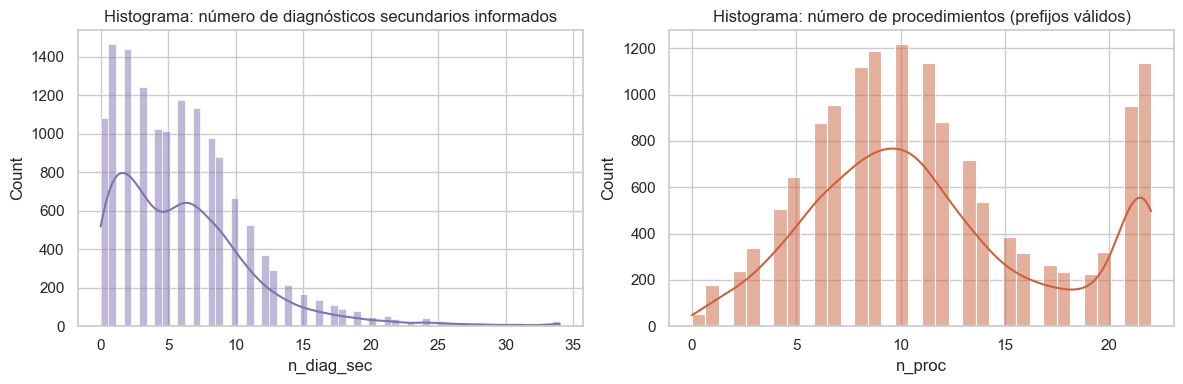

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_df["n_diag_sec"], kde=True, ax=ax[0], color="#8172B2")
ax[0].set_title("Histograma: número de diagnósticos secundarios informados")
sns.histplot(X_df["n_proc"], kde=True, ax=ax[1], color="#CC613E")
ax[1].set_title("Histograma: número de procedimientos (prefijos válidos)")
plt.tight_layout()
plt.show()


In [10]:
numeric_features = [c for c in X_df.columns if c != "sexo"]
categorical_features = ["sexo"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X = X_df
print(numeric_features[:10], "... total num:", len(numeric_features))


['edad', 'n_diag_sec', 'n_proc', 'sec_letter_A', 'sec_letter_B', 'sec_letter_C', 'sec_letter_D', 'sec_letter_E', 'sec_letter_F', 'sec_letter_G'] ... total num: 59


## 4. Análisis exploratorio de datos (EDA)

Se analiza **completitud**, **calidad**, **valores atípicos** en edad y la **distribución de la variable objetivo**.  
Las correlaciones se calculan sobre la matriz numérica ya agregada (útil para detectar redundancias entre conteos).

El código **GRD** agrupa el episodio con fines de gestión; a continuación se muestra su distribución marginal **solo con fines descriptivos** (no se usa como predictor en `X`).


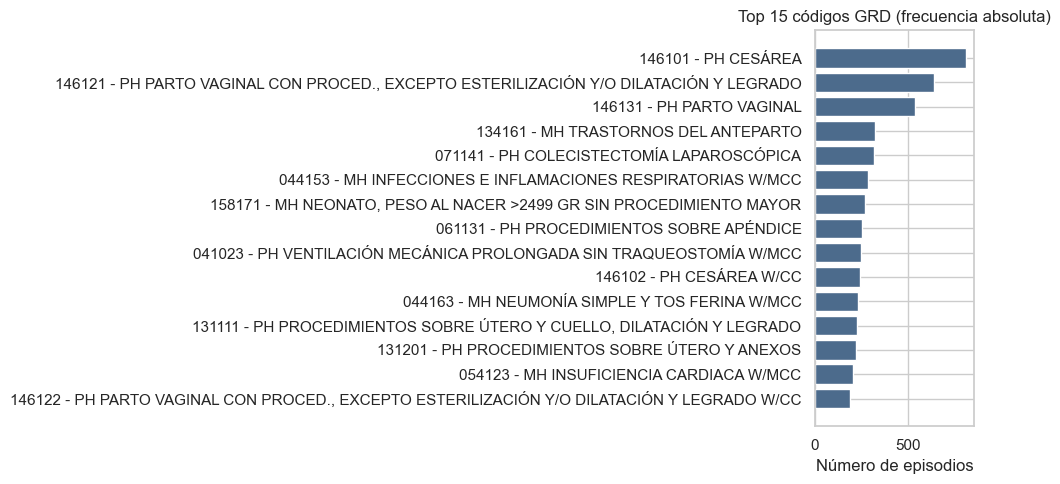

In [11]:
plt.figure(figsize=(10, 5))
top_grd = df["GRD"].astype(str).value_counts().head(15)
plt.barh(top_grd.index[::-1], top_grd.values[::-1], color="#4C6B8C")
plt.title("Top 15 códigos GRD (frecuencia absoluta)")
plt.xlabel("Número de episodios")
plt.tight_layout()
plt.show()


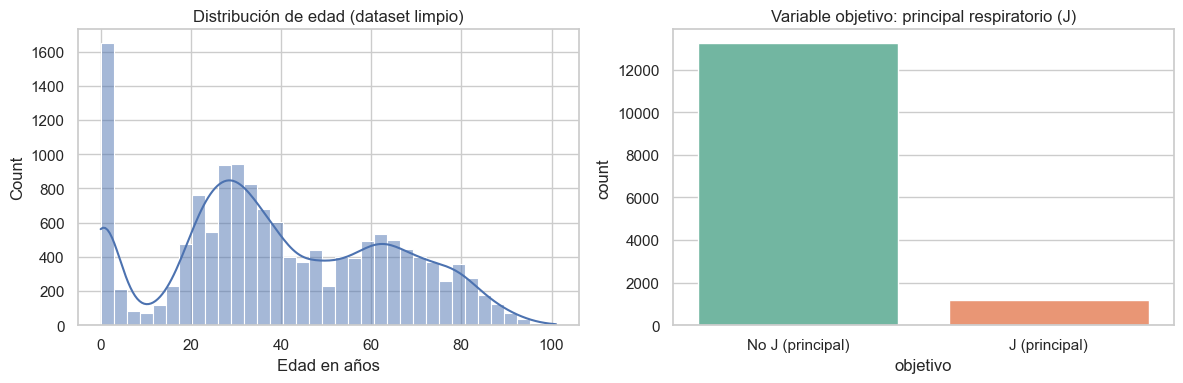

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df[age_col], kde=True, ax=ax[0], color="#4C72B0")
ax[0].set_title("Distribución de edad (dataset limpio)")
obj_df = pd.DataFrame(
    {"objetivo": np.where(y.to_numpy() == 1, "J (principal)", "No J (principal)")}
)
sns.countplot(data=obj_df, x="objetivo", ax=ax[1], hue="objetivo", palette="Set2", legend=False)
ax[1].set_title("Variable objetivo: principal respiratorio (J)")
plt.tight_layout()
plt.show()


{'Q1': np.float64(24.0), 'Q3': np.float64(60.0), 'IQR': np.float64(36.0), 'lim_inf': np.float64(-30.0), 'lim_sup': np.float64(114.0), 'n_outliers_IQR': 0}


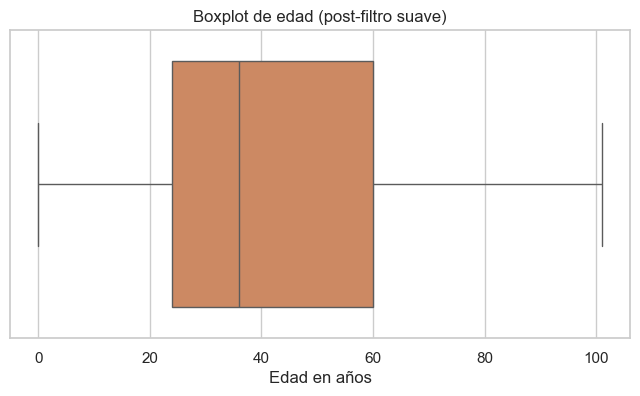

In [13]:
# Outliers edad (IQR) — reporte, sin eliminar agresivamente (ya acotamos [0,110])
q1 = df[age_col].quantile(0.25)
q3 = df[age_col].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr
out_mask = (df[age_col] < low) | (df[age_col] > high)
print({"Q1": q1, "Q3": q3, "IQR": iqr, "lim_inf": low, "lim_sup": high, "n_outliers_IQR": int(out_mask.sum())})

plt.figure(figsize=(8, 4))
sns.boxplot(x=df[age_col], color="#DD8452")
plt.title("Boxplot de edad (post-filtro suave)")
plt.show()


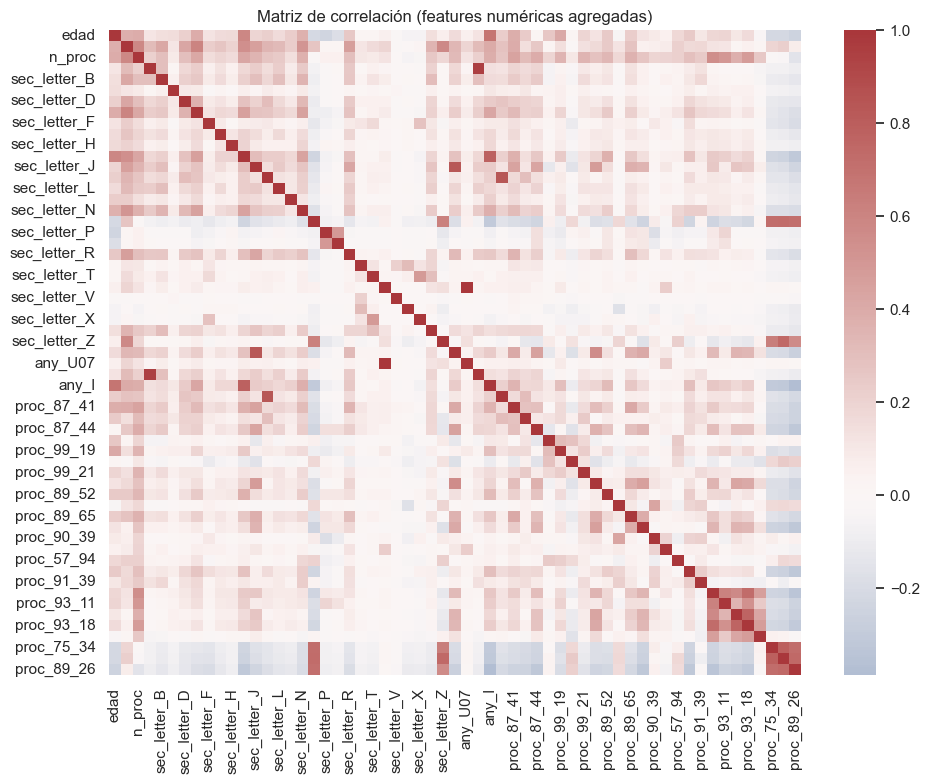

In [14]:
plt.figure(figsize=(10, 8))
corr = X_df.drop(columns=["sexo"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Matriz de correlación (features numéricas agregadas)")
plt.tight_layout()
plt.show()


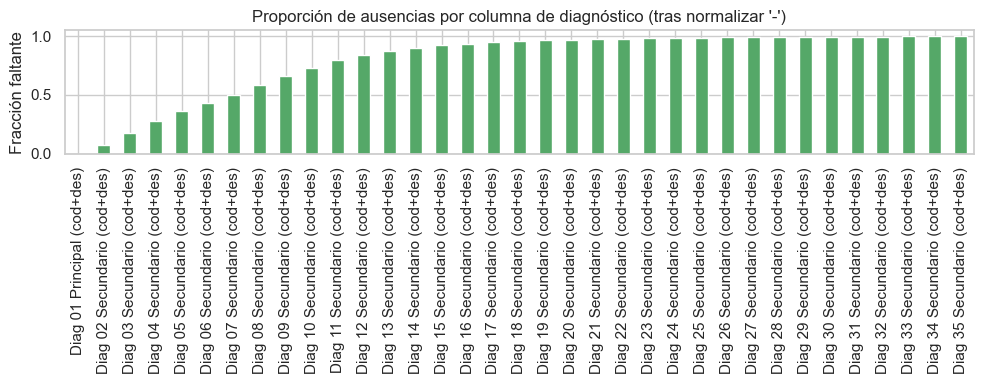

In [15]:
# Completitud en crudo (después de dash -> NaN) en diagnósticos
miss = df[diag_cols].isna().mean().sort_values()
plt.figure(figsize=(10, 4))
miss.plot(kind="bar", color="#55A868")
plt.title("Proporción de ausencias por columna de diagnóstico (tras normalizar '-')")
plt.ylabel("Fracción faltante")
plt.tight_layout()
plt.show()


### Hallazgos clave (interpretación)

- La variable objetivo es **desbalanceada** (la mayoría de episodios no tienen un principal `J`), lo que obliga a interpretar la **exactitud (*accuracy*)** con cautela y privilegiar **F1**, **recall/precisión** y **AUC-ROC**.  
- La edad muestra una distribución **asimétrica** típologías hospitalarias (mezcla obstétrica + adultos).  
- Las columnas de diagnóstico secundario incrementan monotónicamente la ausencia hacia posiciones altas: es esperable en codificación clínica (campos no usados).


## 5. Modelado (*Random Forest*)

Se divide en entrenamiento y prueba con **estratificación** sobre `y`.  
Se entrena un `RandomForestClassifier` con `class_weight='balanced'` para mitigar el desbalance de clases.


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)

model = Pipeline(steps=[("prep", preprocess), ("clf", rf)])
model.fit(X_train, y_train)
print("Entrenamiento completado.")


Entrenamiento completado.


## 6. Evaluación

Se reportan métricas de clasificación. **MAE/MSE** no son estándar para etiquetas discretas; aquí se calculan, **a título ilustrativo**, entre `y` y la **probabilidad estimada de la clase positiva** (error de calibración punto a punto). Para clasificación, las métricas canónicas siguen siendo precisión/recall/F1/AUC.


In [17]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

mae_prob = mean_absolute_error(y_test, y_proba)
mse_prob = mean_squared_error(y_test, y_proba)

print(
    pd.Series(
        {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "roc_auc": auc,
            "mae(y, p1) ilustrativo": mae_prob,
            "mse(y, p1) ilustrativo": mse_prob,
        }
    ).round(4)
)

print("\nclassification_report:\n")
print(classification_report(y_test, y_pred, digits=3))


accuracy                  0.9603
precision                 0.9231
recall                    0.5657
f1                        0.7015
roc_auc                   0.9636
mae(y, p1) ilustrativo    0.0651
mse(y, p1) ilustrativo    0.0308
dtype: float64

classification_report:

              precision    recall  f1-score   support

           0      0.962     0.996     0.979      3307
           1      0.923     0.566     0.701       297

    accuracy                          0.960      3604
   macro avg      0.943     0.781     0.840      3604
weighted avg      0.959     0.960     0.956      3604



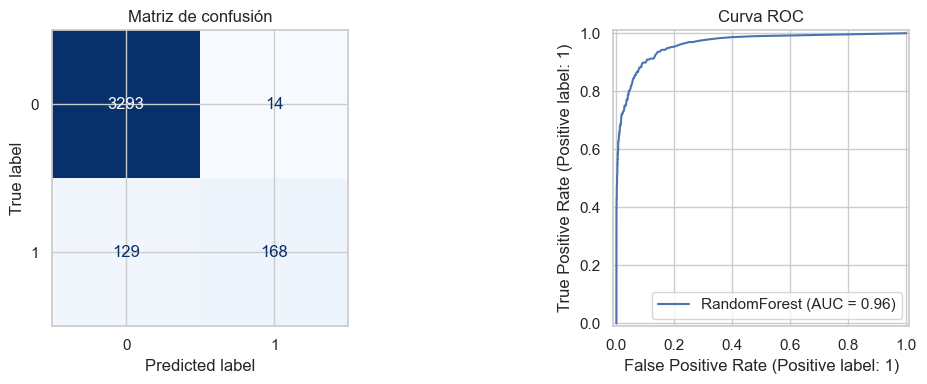

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax[0], cmap="Blues", colorbar=False)
ax[0].set_title("Matriz de confusión")
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax[1], name="RandomForest")
ax[1].set_title("Curva ROC")
plt.tight_layout()
plt.show()


## 7. Visualizaciones del modelo

- **Importancia de variables:** se promedian las importancias del bosque (*Gini importance*).  
- **Pérdida vs épocas:** *Random Forest* no optimiza iterativamente con *epochs* como una red neuronal. En su lugar, se muestra la evolución del **error OOB** (estimación interna de generalización) al incrementar el número de árboles, como analogía de "mejora con más iteraciones de ensamble".


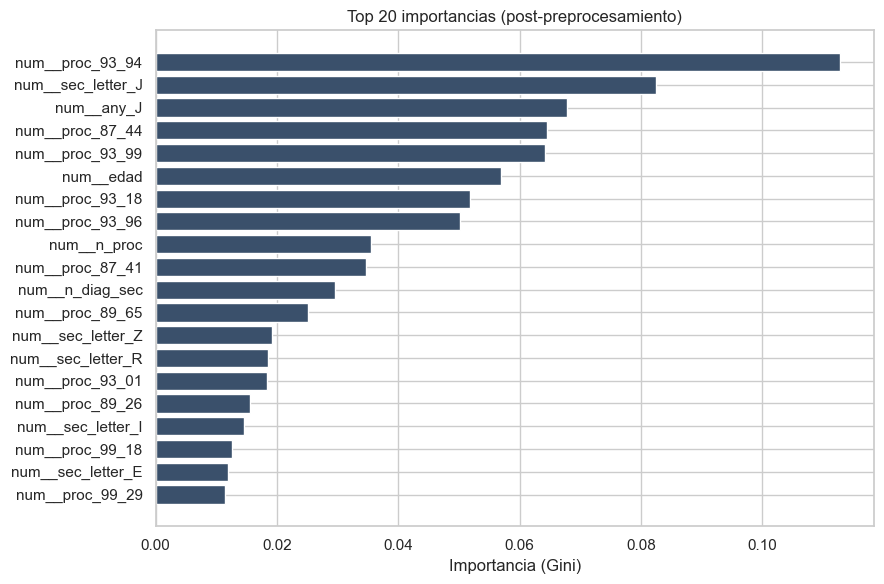

In [19]:
clf: RandomForestClassifier = model.named_steps["clf"]
prep: ColumnTransformer = model.named_steps["prep"]

feat_names = prep.get_feature_names_out()
importances = clf.feature_importances_
imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(20)

plt.figure(figsize=(9, 6))
plt.barh(imp.index.astype(str), imp.values, color="#3A506B")
plt.gca().invert_yaxis()
plt.title("Top 20 importancias (post-preprocesamiento)")
plt.xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()


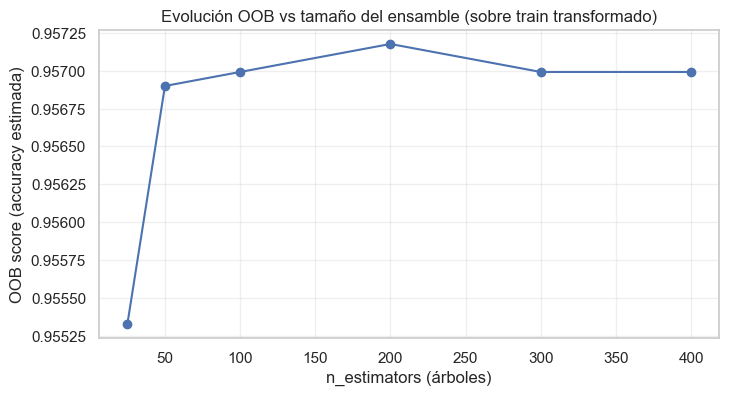

In [20]:
# Analogía de "curva de aprendizaje": OOB score vs n_estimators
# (comentario pedagógico: no hay epochs; el ensamble agrega árboles de forma independiente)

from sklearn.ensemble import RandomForestClassifier as RFC

prep_fitted: ColumnTransformer = model.named_steps["prep"]
Xtr = prep_fitted.transform(X_train)

sizes = [25, 50, 100, 200, 300, 400]
oob_scores = []

for n in sizes:
    r = RFC(
        n_estimators=n,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced",
        oob_score=True,
        bootstrap=True,
    )
    r.fit(Xtr, y_train)
    oob_scores.append(r.oob_score_)

plt.figure(figsize=(8, 4))
plt.plot(sizes, oob_scores, marker="o")
plt.xlabel("n_estimators (árboles)")
plt.ylabel("OOB score (accuracy estimada)")
plt.title("Evolución OOB vs tamaño del ensamble (sobre train transformado)")
plt.grid(True, alpha=0.3)
plt.show()
